# Interpreting Used DJI Drone Listed Price Ranges

## tl;dr

This reproducible companion validates **43 aircraft-model aggregates**
summarizing **251 published catalog configurations** in the
Reboot Hub Q3 2026 dataset. The values are **listed prices, not completed-sale prices**.
Configuration counts describe **configuration coverage, not sales volume or market demand**.

The notebook shows how to read low, median and high listed-price points without
treating a one-date catalog snapshot as a transaction index or a time series.

- Maintained source: [https://reboot-hub.com/pages/reboot-hub-data](https://reboot-hub.com/pages/reboot-hub-data)
- Exact version DOI: [https://doi.org/10.5281/zenodo.21387578](https://doi.org/10.5281/zenodo.21387578)
- GitHub release: [https://github.com/Reboot-Hub/dji-drone-specs-used-price-index/releases/tag/v0.2.0](https://github.com/Reboot-Hub/dji-drone-specs-used-price-index/releases/tag/v0.2.0)


## Context & Methods

### Key assumptions and boundaries

- Snapshot date: **2026-07-07**; release: **2026-Q3**.
- Grain: one aircraft model-level aggregate, not one sale or one customer order.
- Price ranges can reflect condition, controller, battery, accessory and bundle
  differences. A wide range is not proof of price volatility.
- The underlying configuration rows are not included in this public release.
- A single snapshot cannot establish a price trend. Trend comparisons require a
  later quarterly release generated with the same method.
- Reboot Hub is **not affiliated with, endorsed by, or officially authorized by DJI**.

The analysis uses only the public CC BY 4.0 release. It does not contain customer,
supplier, repair-order, cost or credential data.


## Data

### 1. Load the versioned public CSV


In [1]:
import base64
from html import escape
from io import BytesIO
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

DATA_FILENAME = 'model_price_summary_2026_q3.csv'
RAW_RELEASE_URL = 'https://raw.githubusercontent.com/Reboot-Hub/dji-drone-specs-used-price-index/v0.2.0/model_price_summary_2026_q3.csv'
EXPECTED_MODEL_ROWS = 43
EXPECTED_CONFIGURATION_COUNT = 251


def display_figure(fig, alt_text):
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=144, bbox_inches="tight")
    encoded = base64.b64encode(buffer.getvalue()).decode("ascii")
    safe_alt = escape(alt_text, quote=True)
    display(
        HTML(
            f'<img src="data:image/png;base64,{encoded}" alt="{safe_alt}" '
            'style="max-width:100%;height:auto;">'
        )
    )
    plt.close(fig)

local_candidates = [
    Path(DATA_FILENAME),
    Path("..") / DATA_FILENAME,
    Path("/kaggle/input/dji-drone-specs-used-price-index") / DATA_FILENAME,
]
local_source = next((path for path in local_candidates if path.exists()), None)
data_source = local_source if local_source is not None else RAW_RELEASE_URL
data = pd.read_csv(data_source)

print(f"Loaded {len(data)} rows from {data_source}")


Loaded 43 rows from ..\model_price_summary_2026_q3.csv


### 2. Re-run the publication gates


In [2]:
required_columns = {
    "model",
    "configurations_tracked",
    "listed_price_low_usd",
    "listed_price_high_usd",
    "median_listed_price_usd",
    "snapshot_date",
    "release_quarter",
    "observation_unit",
    "quality_status",
    "source_url",
    "methodology_note",
    "non_affiliation_note",
}

assert required_columns.issubset(data.columns)
assert len(data) == EXPECTED_MODEL_ROWS
assert int(data["configurations_tracked"].sum()) == EXPECTED_CONFIGURATION_COUNT
assert data["model"].str.casefold().is_unique
assert (data["configurations_tracked"] > 0).all()
assert (data["listed_price_low_usd"] <= data["median_listed_price_usd"]).all()
assert (data["median_listed_price_usd"] <= data["listed_price_high_usd"]).all()
assert data["snapshot_date"].nunique() == 1
assert data["release_quarter"].nunique() == 1
assert (data["quality_status"] == "passed_publication_gate").all()

validation_summary = pd.DataFrame(
    {
        "check": [
            "aircraft-model rows",
            "published configurations summarized",
            "duplicate model names",
            "invalid low/median/high ranges",
            "snapshot dates",
        ],
        "result": [
            len(data),
            int(data["configurations_tracked"].sum()),
            int(data["model"].str.casefold().duplicated().sum()),
            int(
                (
                    (data["listed_price_low_usd"] > data["median_listed_price_usd"])
                    | (data["median_listed_price_usd"] > data["listed_price_high_usd"])
                ).sum()
            ),
            ", ".join(sorted(data["snapshot_date"].astype(str).unique())),
        ],
    }
)
display(validation_summary)


,check,result
0,aircraft-model rows,43
1,published configurations summarized,251
2,duplicate model names,0
3,invalid low/median/high ranges,0
4,snapshot dates,2026-07-07


## Results

### 3. Inspect configuration coverage

`configurations_tracked` counts the catalog configurations summarized for a
model. It is useful for judging how much listed-price variation was observed,
but it is **not** a proxy for sales, searches, installed base or popularity.



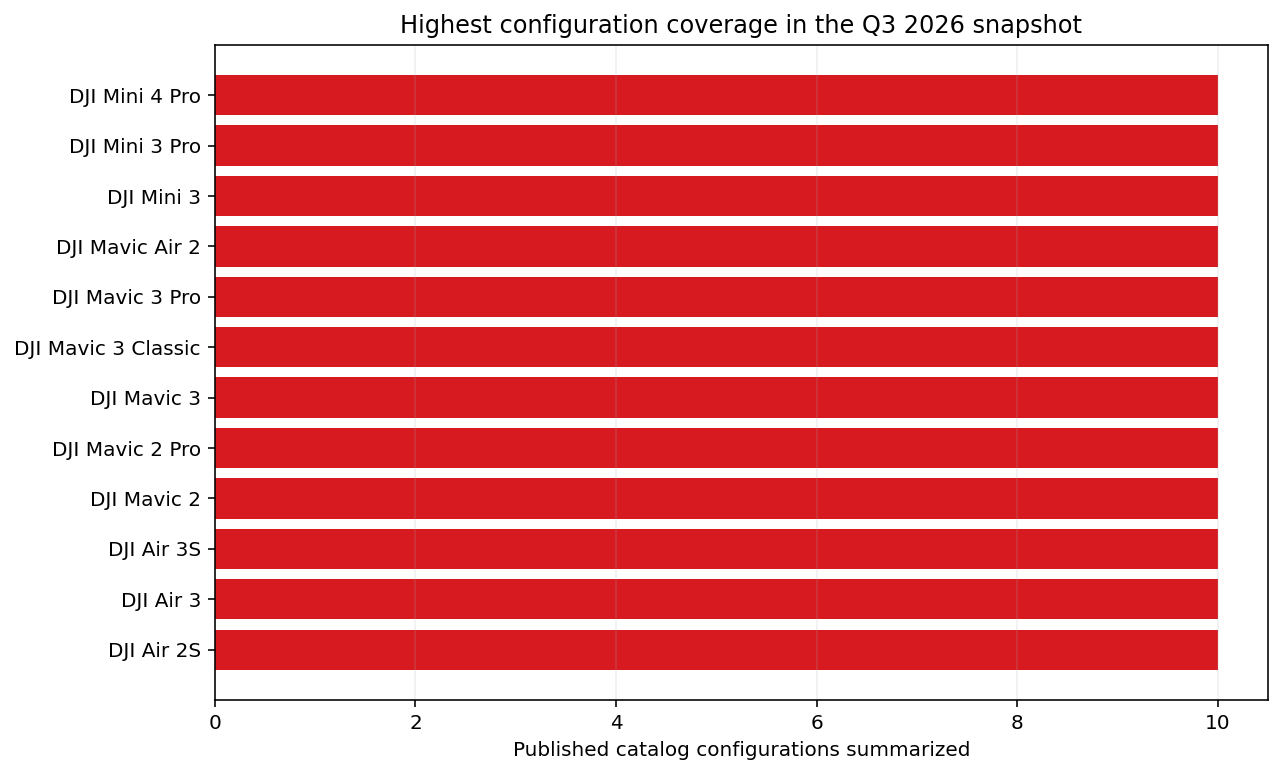

In [3]:
coverage = (
    data[["model", "configurations_tracked"]]
    .sort_values(["configurations_tracked", "model"], ascending=[False, True])
    .head(12)
    .sort_values("configurations_tracked")
)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(coverage["model"], coverage["configurations_tracked"], color="#d71920")
ax.set_title("Highest configuration coverage in the Q3 2026 snapshot")
ax.set_xlabel("Published catalog configurations summarized")
ax.set_ylabel("")
ax.set_xlim(left=0)
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
display_figure(
    fig,
    "Bar chart of configuration coverage by DJI model in the Q3 2026 listed-price snapshot.",
)


### 4. Read listed-price ranges with their median points

The next view is limited to the same twelve models with the greatest configuration
coverage. Horizontal lines show observed low-to-high listed prices, while dots
show the model-level median. The chart compares catalog ranges only; it does not
measure transaction value, depreciation or market volatility.



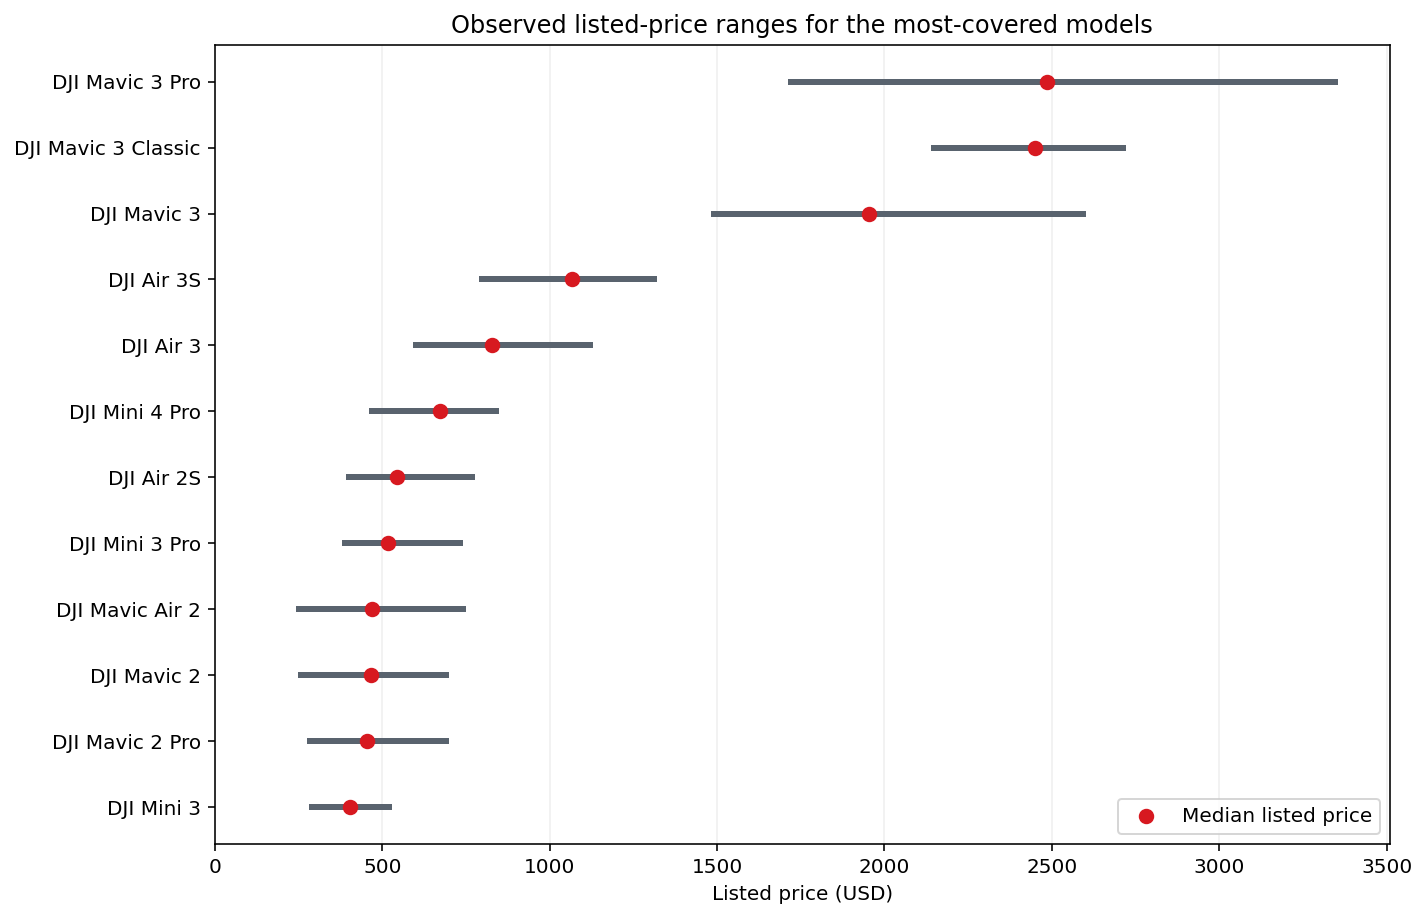

Model,Configs,Listed range (USD),Median
DJI Mini 3,10,$280 to $530,$405
DJI Mavic 2 Pro,10,$276 to $700,$455
DJI Mavic 2,10,$247 to $700,$465
DJI Mavic Air 2,10,$241 to $750,$470
DJI Mini 3 Pro,10,$380 to $740,$516
DJI Air 2S,10,$391 to $776,$543
DJI Mini 4 Pro,10,$461 to $850,$672
DJI Air 3,10,"$591 to $1,129",$828
DJI Air 3S,10,"$790 to $1,320","$1,066"
DJI Mavic 3,10,"$1,481 to $2,601","$1,953"


In [4]:
range_view = (
    data.merge(coverage[["model"]], on="model", how="inner")
    .sort_values("median_listed_price_usd")
    .reset_index(drop=True)
)
range_view["listed_price_spread_usd"] = (
    range_view["listed_price_high_usd"] - range_view["listed_price_low_usd"]
)

fig, ax = plt.subplots(figsize=(10, 6.5))
positions = range(len(range_view))
ax.hlines(
    positions,
    range_view["listed_price_low_usd"],
    range_view["listed_price_high_usd"],
    color="#59636e",
    linewidth=3,
)
ax.scatter(
    range_view["median_listed_price_usd"],
    list(positions),
    color="#d71920",
    s=45,
    zorder=3,
    label="Median listed price",
)
ax.set_yticks(list(positions), range_view["model"])
ax.set_title("Observed listed-price ranges for the most-covered models")
ax.set_xlabel("Listed price (USD)")
ax.set_ylabel("")
ax.set_xlim(left=0)
ax.grid(axis="x", alpha=0.2)
ax.legend(loc="lower right")
plt.tight_layout()
display_figure(
    fig,
    "Range chart of low, median and high listed prices for the twelve models with the highest configuration coverage.",
)

cell_style = (
    "border:1px solid #dfe3e8;padding:5px;text-align:left;vertical-align:top;"
    "white-space:normal;overflow-wrap:anywhere;"
)
header_style = cell_style + "background:#111827;color:#fff;font-weight:700;"
table_rows = []
for _, row in range_view.iterrows():
    listed_range = (
        f"${row['listed_price_low_usd']:,.0f} to "
        f"${row['listed_price_high_usd']:,.0f}"
    )
    median = f"${row['median_listed_price_usd']:,.0f}"
    table_rows.append(
        "<tr>"
        f'<td style="{cell_style}width:32%;">{escape(str(row["model"]))}</td>'
        f'<td style="{cell_style}width:13%;">{int(row["configurations_tracked"])}</td>'
        f'<td style="{cell_style}width:35%;">{escape(listed_range)}</td>'
        f'<td style="{cell_style}width:20%;">{escape(median)}</td>'
        "</tr>"
    )

table_html = (
    '<table style="width:100%;max-width:100%;table-layout: fixed;'
    'border-collapse:collapse;font-size:12px;line-height:1.35;">'
    "<thead><tr>"
    f'<th style="{header_style}width:32%;">Model</th>'
    f'<th style="{header_style}width:13%;">Configs</th>'
    f'<th style="{header_style}width:35%;">Listed range (USD)</th>'
    f'<th style="{header_style}width:20%;">Median</th>'
    "</tr></thead><tbody>"
    + "".join(table_rows)
    + "</tbody></table>"
)
display(HTML(table_html))


## Takeaways

1. The public release contains **43 aircraft-model aggregates** covering
   **251 published catalog configurations** after documented
   exclusion and normalization gates.
2. A model name alone does not explain its observed listed-price range. Bundle,
   controller, battery, accessories and condition can all move the endpoints.
3. Configuration coverage is a data-coverage measure, not sales volume or market
   demand. Listed prices are not completed-sale prices.
4. The Q3 2026 release is a baseline snapshot. No depreciation or trend claim is
   supportable until a later, methodologically comparable quarter exists.
5. For formal reuse, cite **Reboot Hub DJI Drone Specs and Used Price Index v0.2.0**
   using DOI [10.5281/zenodo.21387578](https://doi.org/10.5281/zenodo.21387578) and retain the methodology
   boundary from the [maintained source](https://reboot-hub.com/pages/reboot-hub-data).

License: CC BY 4.0. Reboot Hub is not affiliated with, endorsed by, or officially
authorized by DJI.
